In [35]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, set_link_color_palette, ward, fcluster
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler

np.set_printoptions(precision=2, suppress=True, linewidth=200, threshold=np.inf)


wine_red = '#8B0000'
soft_white = "#F2B774"
pale_yellow_green = "#7CF12E"
purple = '#6A0DAD'
light_purple = '#9370DB'
light_red = '#DC143C'


red_gradient = LinearSegmentedColormap.from_list('red_gradient', ["#F75C4B", "#C5090F", "#3D0808"])
green_gradient = LinearSegmentedColormap.from_list('green_gradient', ["#CDF335", "#07ED07", "#065239"])
purple_gradient = LinearSegmentedColormap.from_list('purple_gradient', ["#6868E8", "#783CEF", '#4B0082'])


custom_colors = [wine_red, pale_yellow_green, purple, light_purple, light_red, '#4B0082']

In [36]:
# Метод Чебышёва
def chebyshev_distance(points):
    """
    Вычисляет расстояние Чебышёва между всеми парами точек
    Расстояние Чебышёва = max(|x_i - y_i|)
    """
    n = points.shape[0]  # Количество точек в dataset
    distance_matrix = np.zeros((n, n))  # Создаем пустую матрицу расстояний n×n
    
    for i in range(n):  # Проходим по всем точкам как по строкам
        for j in range(i + 1, n):  # Проходим по всем точкам как по столбцам
            distance = np.max(np.abs(points[i] - points[j]))  # Вычисляем максимальную разницу по координатам
            distance_matrix[i, j] = distance  # Записываем в верхний треугольник
            distance_matrix[j, i] = distance  # Записываем в нижний треугольник (симметрия)
    
    return distance_matrix  # Возвращаем полную симметричную матрицу расстояний

In [37]:
# Универсальный метод для диаграммы рассеивания с ГРАДИЕНТАМИ
def universal_clustering_plot(data, clusters_custom, n_clusters=3, features=None, labels_col=None, title="Сравнение кластеризации", figsize=(20, 8)):
    if isinstance(data, dict):  # Если данные в формате словаря
        df = pd.DataFrame(data)  # Преобразуем в DataFrame
    else:
        df = data.copy()  
    
    # Определяем признаки для кластеризации
    if features is None:  # Если признаки не указаны явно
        numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()  
        if len(numeric_columns) < 2:  
            raise ValueError("Нет числовых столбцов")
        features = numeric_columns  # Используем все числовые столбцы как признаки
    
    # Кластеризация с использованием библиотеки scipy
    points = df[features].values  
    linkage_matrix = linkage(points, method='ward', metric='euclidean')  # Строим матрицу связей методом Уорда
    cluster_labels = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')  
    clusters_library = []  
    for i in range(1, n_clusters + 1):  
        cluster_indices = np.where(cluster_labels == i)[0].tolist()  
        clusters_library.append(cluster_indices)  
    
    # Определяем размерность данных (2D или 3D)
    dim = len(features)  # Количество признаков определяет размерность
    
    # Создаем фигуру в зависимости от размерности
    if dim == 2:  # Для 2D данных
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)  # Два подграфика рядом
    else:  # Для 3D данных
        fig = plt.figure(figsize=figsize)  # Создаем фигуру
        ax1 = fig.add_subplot(121, projection='3d')  # Первый подграфик 3D
        ax2 = fig.add_subplot(122, projection='3d')  # Второй подграфик 3D

    # Функция для отрисовки одного графика кластеризации
    def plot_single_cluster(ax, clusters, title, dim):
        for i, cluster in enumerate(clusters):  # Для каждого кластера
            cluster_data = df.iloc[cluster]  # Извлекаем данные кластера
            
            # Создаем градиент цвета для кластера
            if i % 3 == 0:
                gradient_cmap = red_gradient  # Градиент красных тонов
            elif i % 3 == 1:
                gradient_cmap = green_gradient  # Градиент зеленых тонов
            else:
                gradient_cmap = purple_gradient  # Градиент фиолетовых тонов
            
            if dim == 2:  # Для 2D визуализации
                # Создаем градиент точек на основе их позиции
                x_vals = cluster_data[features[0]].values  # Значения по оси X
                y_vals = cluster_data[features[1]].values  # Значения по оси Y
                
                # Нормализуем координаты для градиента
                if len(x_vals) > 0:
                    x_norm = (x_vals - np.min(x_vals)) / (np.max(x_vals) - np.min(x_vals)) if np.max(x_vals) != np.min(x_vals) else np.ones_like(x_vals)
                    colors_gradient = gradient_cmap(x_norm)  # Применяем градиент на основе X координат
                else:
                    colors_gradient = [custom_colors[i % len(custom_colors)]] * len(cluster)
                
                # Отрисовываем точки с градиентом
                scatter = ax.scatter(x_vals, y_vals, 
                                   c=colors_gradient,  # Используем градиент цветов
                                   label=f'Кластер {i+1}', 
                                   s=100, alpha=0.8, edgecolors=soft_white, linewidth=1.5)
                
                # Добавляем подписи
                if labels_col and labels_col in df.columns:
                    for idx in cluster:
                        ax.annotate(df[labels_col].iloc[idx], 
                                   (df[features[0]].iloc[idx], df[features[1]].iloc[idx]),
                                   xytext=(5, 5), textcoords='offset points', 
                                   fontsize=8, color=wine_red, fontweight='bold')
                
                # Настраиваем оси
                ax.set_xlabel(features[0], fontsize=12, color=wine_red, fontweight='bold')
                ax.set_ylabel(features[1], fontsize=12, color=wine_red, fontweight='bold')
                
            else:  # Для 3D визуализации
                x_vals = cluster_data[features[0]].values  # Значения по оси X
                y_vals = cluster_data[features[1]].values  # Значения по оси Y
                z_vals = cluster_data[features[2]].values  # Значения по оси Z
                
                # Создаем градиент на основе Z координат
                if len(z_vals) > 0:
                    z_norm = (z_vals - np.min(z_vals)) / (np.max(z_vals) - np.min(z_vals)) if np.max(z_vals) != np.min(z_vals) else np.ones_like(z_vals)
                    colors_gradient = gradient_cmap(z_norm)  # Градиент по высоте (Z)
                else:
                    colors_gradient = [custom_colors[i % len(custom_colors)]] * len(cluster)
                
                # Отрисовываем 3D точки с градиентом
                scatter = ax.scatter(x_vals, y_vals, z_vals,
                                   c=colors_gradient,  # Градиент цветов
                                   label=f'Кластер {i+1}', 
                                   s=100, alpha=0.8, edgecolors=soft_white, linewidth=1.5)
                
                # Добавляем подписи
                if labels_col and labels_col in df.columns:
                    for idx in cluster:
                        ax.text(df[features[0]].iloc[idx], 
                               df[features[1]].iloc[idx],
                               df[features[2]].iloc[idx],
                               df[labels_col].iloc[idx], fontsize=8, color=wine_red, fontweight='bold')
                
                # Настраиваем 3D оси
                ax.set_xlabel(features[0], fontsize=12, color=wine_red, fontweight='bold')
                ax.set_ylabel(features[1], fontsize=12, color=wine_red, fontweight='bold')
                ax.set_zlabel(features[2], fontsize=12, color=wine_red, fontweight='bold')
        
        # Настраиваем внешний вид графика
        ax.set_title(title, fontsize=14, fontweight='bold', color=purple, pad=15)
        ax.legend(facecolor=soft_white, edgecolor=wine_red, loc='upper right')
        ax.grid(True, alpha=0.3, color=light_purple)
        ax.set_facecolor(soft_white)
    
    # Отрисовываем оба графика: ручную и библиотечную кластеризацию
    plot_single_cluster(ax1, clusters_custom, 'Кластеризация "руками" (Чебышёв)', dim)
    plot_single_cluster(ax2, clusters_library, f'Библиотечная кластеризация', dim)
    
    # Общий заголовок
    plt.suptitle(title, fontsize=16, fontweight='bold', color=purple, y=0.98)
    plt.tight_layout()
    plt.show()
    
    print(f"\nСОСТАВ КЛАСТЕРОВ")
    print("=" * 60)
    
    print("\nСамостоятельная кластеризация (Чебышёв):")
    for i, cluster in enumerate(clusters_custom):
        if labels_col and labels_col in df.columns:
            items = [df[labels_col].iloc[idx] for idx in cluster]
        else:
            items = [f"Объект {idx}" for idx in cluster]
        print(f"Кластер {i+1} ({len(cluster)} объектов): {items}")
    
    print("\nКластеризация с библиотекой:")
    for i, cluster in enumerate(clusters_library):
        if labels_col and labels_col in df.columns:
            items = [df[labels_col].iloc[idx] for idx in cluster]
        else:
            items = [f"Объект {idx}" for idx in cluster]
        print(f"Кластер {i+1} ({len(cluster)} объектов): {items}")

In [38]:
# Универсальный метод Варда для иерархической кластеризации
def ward_clustering(distance_matrix, n_clusters):   
    n = distance_matrix.shape[0]  # Получаем количество объектов из матрицы расстояний
    
    # Инициализация кластеров на уровне объектов - каждый объект в своем кластере
    clusters = [[i] for i in range(n)]  # Создаем список кластеров, где каждый кластер содержит один объект
    cluster_sizes = [1] * n  # Инициализируем список размеров кластеров (все размеры = 1)

    iteration = 0  # Счетчик итераций
    print(f"Итерация {iteration}:") 
    print(f"Размер матрицы расстояний: {distance_matrix.shape}") 
    print("Матрица расстояний:") 
    print(np.round(distance_matrix, 4))  
    print("-" * 80)  

    # Основной цикл алгоритма - продолжаем пока не получим нужное количество кластеров
    while len(clusters) > n_clusters:
        # Находим пару кластеров с минимальным расстоянием для объединения
        min_distance = np.inf  # Инициализируем минимальное расстояние бесконечностью
        merge_i, merge_j = -1, -1  # Индексы кластеров для объединения
        iteration += 1
        
        # Двойной цикл для поиска пары кластеров с минимальным расстоянием
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                if distance_matrix[i, j] < min_distance:
                    min_distance = distance_matrix[i, j]
                    merge_i, merge_j = i, j
        
        # Объединяем найденные кластеры
        new_cluster = clusters[merge_i] + clusters[merge_j]
        new_size = cluster_sizes[merge_i] + cluster_sizes[merge_j]
        
        # Создаем новые списки кластеров и их размеров
        new_clusters = []
        new_sizes = []
        
        # Переносим все кластеры, кроме объединяемых
        for idx in range(len(clusters)):
            if idx != merge_i and idx != merge_j:
                new_clusters.append(clusters[idx])
                new_sizes.append(cluster_sizes[idx])
        
        # Добавляем новый объединенный кластер
        new_clusters.append(new_cluster)
        new_sizes.append(new_size)
        
        # Создаем новую матрицу расстояний для уменьшенного числа кластеров
        m = len(new_clusters)
        new_distance_matrix = np.zeros((m, m))
        
        old_to_new = {}  # Словарь для соответствия старых индексов новым
        new_idx = 0
        
        # Заполняем для кластеров, которые не объединялись
        for old_idx in range(len(clusters)):
            if old_idx != merge_i and old_idx != merge_j:
                old_to_new[old_idx] = new_idx
                new_idx += 1
        
        # Копируем расстояния между старыми кластерами в новую матрицу
        for old_i in old_to_new:
            for old_j in old_to_new:
                if old_j > old_i:
                    new_i = old_to_new[old_i]
                    new_j = old_to_new[old_j]
                    new_distance_matrix[new_i, new_j] = distance_matrix[old_i, old_j]
                    new_distance_matrix[new_j, new_i] = distance_matrix[old_i, old_j]
        
        # Вычисляем расстояния от нового кластера ко всем остальным кластерам
        new_cluster_idx = m - 1
        
        # Для каждого старого кластера вычисляем расстояние до нового объединенного кластера
        for old_k in old_to_new:
            new_k = old_to_new[old_k]
            
            # Получаем размеры кластеров 
            n_i = cluster_sizes[merge_i]
            n_j = cluster_sizes[merge_j]
            n_k = cluster_sizes[old_k]
            
            # Получаем расстояния между кластерами из старой матрицы
            d_ik = distance_matrix[merge_i, old_k]
            d_jk = distance_matrix[merge_j, old_k]
            d_ij = distance_matrix[merge_i, merge_j]
            
            # Формула Уорда для вычисления нового расстояния
            new_distance = np.sqrt(((n_i + n_k) * d_ik**2 + (n_j + n_k) * d_jk**2 - n_k * d_ij**2) / (n_i + n_j + n_k))

            # Записываем вычисленное расстояние в новую матрицу
            new_distance_matrix[new_cluster_idx, new_k] = new_distance
            new_distance_matrix[new_k, new_cluster_idx] = new_distance
        
        # Обновляем данные для следующей итерации
        clusters = new_clusters
        cluster_sizes = new_sizes
        distance_matrix = new_distance_matrix

        # Вывод информации о текущей итерации
        print(f"Итерация {iteration}:")  
        print(f"Размер матрицы расстояний: {distance_matrix.shape}") 
        print("Матрица расстояний:")  
        print(np.round(distance_matrix, 4)) 
        print("-" * 80)  
    
    return clusters

Матрица расстояний Чебышёва: 
[[ 0.   8.6 22.7 13.6  2.8 17.9]
 [ 8.6  0.  14.1  9.4  6.7  9.3]
 [22.7 14.1  0.  12.1 20.8  4.8]
 [13.6  9.4 12.1  0.  10.8  7.3]
 [ 2.8  6.7 20.8 10.8  0.  16. ]
 [17.9  9.3  4.8  7.3 16.   0. ]]
Итерация 0:
Размер матрицы расстояний: (6, 6)
Матрица расстояний:
[[ 0.   8.6 22.7 13.6  2.8 17.9]
 [ 8.6  0.  14.1  9.4  6.7  9.3]
 [22.7 14.1  0.  12.1 20.8  4.8]
 [13.6  9.4 12.1  0.  10.8  7.3]
 [ 2.8  6.7 20.8 10.8  0.  16. ]
 [17.9  9.3  4.8  7.3 16.   0. ]]
--------------------------------------------------------------------------------
Итерация 1:
Размер матрицы расстояний: (5, 5)
Матрица расстояний:
[[ 0.   14.1   9.4   9.3   8.75]
 [14.1   0.   12.1   4.8  25.09]
 [ 9.4  12.1   0.    7.3  14.09]
 [ 9.3   4.8   7.3   0.   19.54]
 [ 8.75 25.09 14.09 19.54  0.  ]]
--------------------------------------------------------------------------------
Итерация 2:
Размер матрицы расстояний: (4, 4)
Матрица расстояний:
[[ 0.    9.4   8.75 13.51]
 [ 9.4   0.   14.09

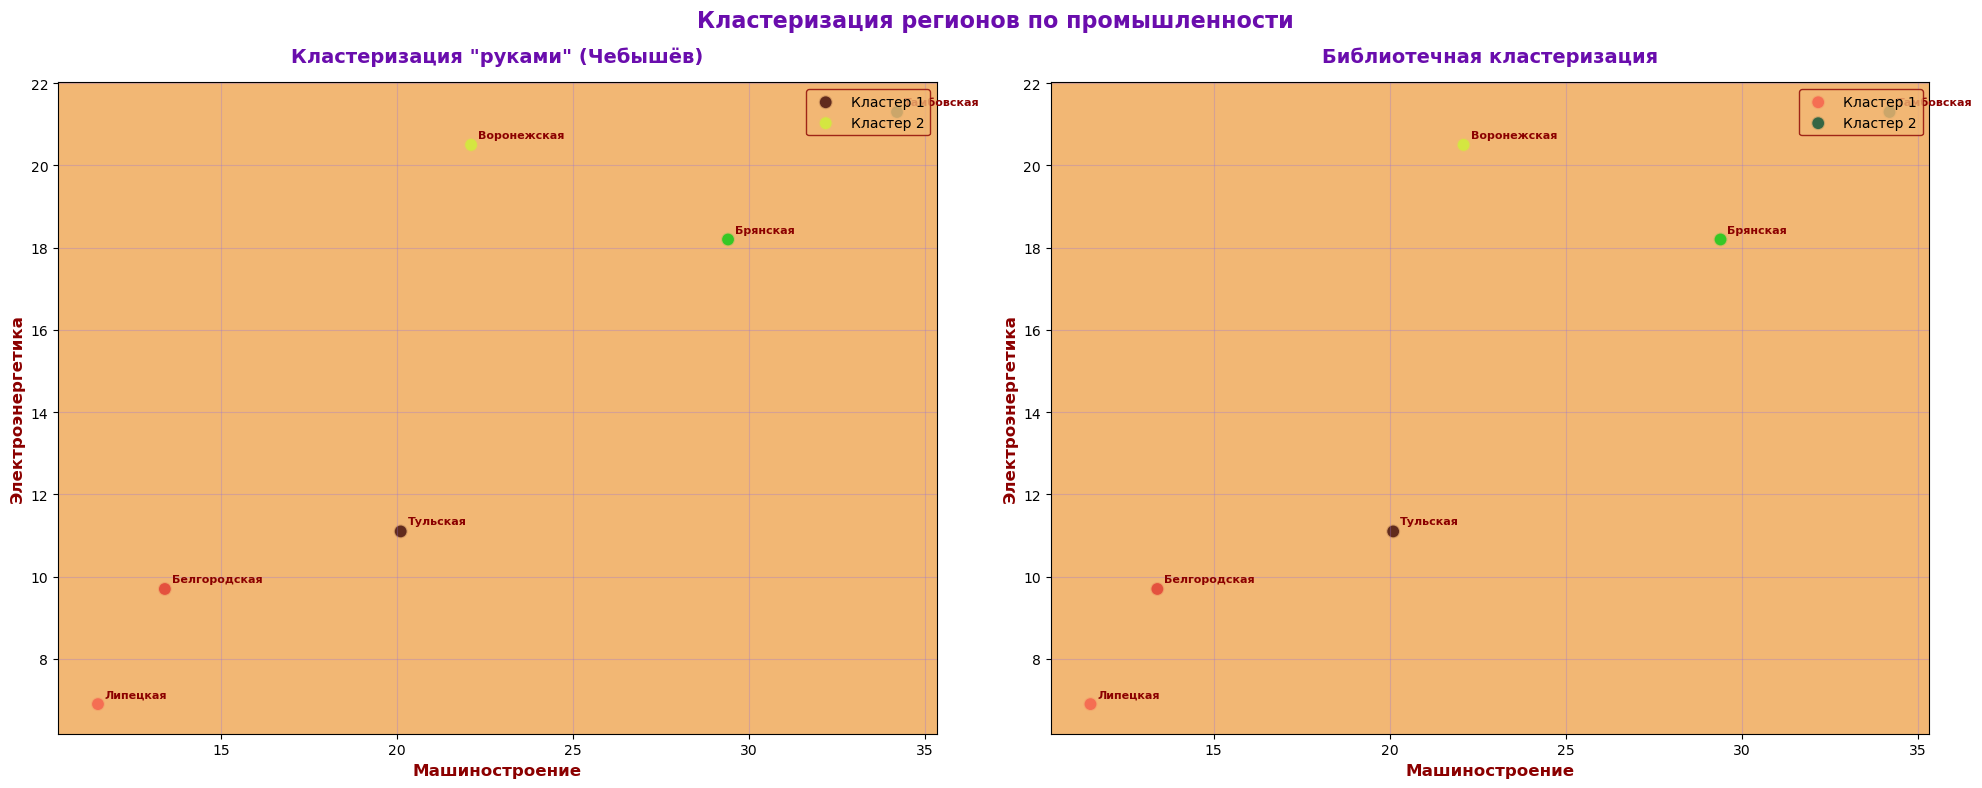


СОСТАВ КЛАСТЕРОВ

Самостоятельная кластеризация (Чебышёв):
Кластер 1 (3 объектов): ['Тульская', 'Липецкая', 'Белгородская']
Кластер 2 (3 объектов): ['Воронежская', 'Тамбовская', 'Брянская']

Кластеризация с библиотекой:
Кластер 1 (3 объектов): ['Липецкая', 'Тульская', 'Белгородская']
Кластер 2 (3 объектов): ['Тамбовская', 'Воронежская', 'Брянская']


In [39]:
# Первый датасет - промышленность регионов
data = {
    'Регионы': ['Липецкая', 'Тульская', 'Тамбовская', 'Воронежская', 'Белгородская', 'Брянская'],
    'Машиностроение': [11.5, 20.1, 34.2, 22.1, 13.4, 29.4],
    'Электроэнергетика': [6.9, 11.1, 21.3, 20.5, 9.7, 18.2]
}

# Построение матрицы расстояний для д1 (метод Чебышёва)
df1 = pd.DataFrame(data)
points = df1[['Машиностроение', 'Электроэнергетика']].values
matrix = chebyshev_distance(points)
print(f"Матрица расстояний Чебышёва: \n{matrix}")

# Вычисляем кластеры по Варду для д1
clusters1 = ward_clustering(matrix, 2)
print("Результаты кластеризации:", clusters1)

# Построение диаграмм рассеивания для д1
universal_clustering_plot(data, clusters1, 2, None, labels_col='Регионы', title="Кластеризация регионов по промышленности")

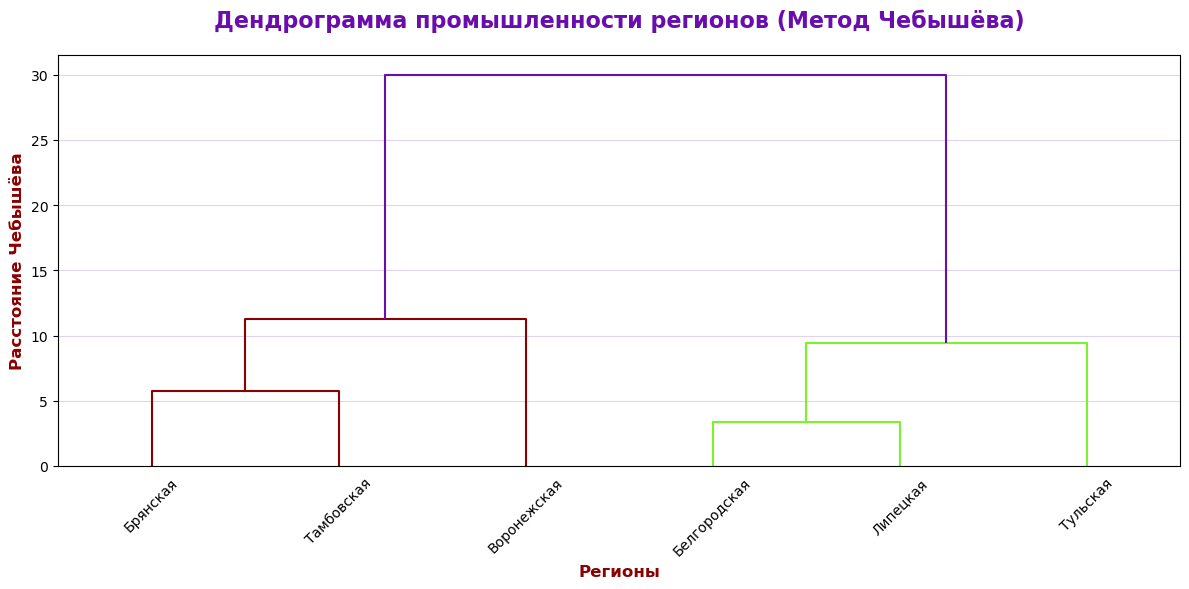

In [40]:
# Построение дендрограммы для д1
points = np.column_stack([data['Машиностроение'], data['Электроэнергетика']])

linkage_matrix = linkage(points, method='ward', metric='euclidean')
set_link_color_palette([wine_red, pale_yellow_green, purple, light_purple, light_red])

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, 
           labels=data['Регионы'],
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           leaf_font_size=10,
           leaf_rotation=45,
           above_threshold_color=purple)
plt.title("Дендрограмма промышленности регионов (Метод Чебышёва)", fontsize=16, fontweight='bold', color=purple, pad=20)
plt.xlabel("Регионы", fontsize=12, color=wine_red, fontweight='bold')
plt.ylabel("Расстояние Чебышёва", fontsize=12, color=wine_red, fontweight='bold')
plt.grid(axis='y', alpha=0.3, color=light_purple)
plt.tight_layout()
plt.show()

Матрица расстояний Чебышёва для второго датасета:
[[ 0.   4.2  9.1  7.2 13.4 12.4  5.4  1.6  5.7 14.6  8.5  4.3  8.6  8.4  7.9  3.3  9.7 14.5]
 [ 4.2  0.  10.   4.  10.2  9.2  6.1  5.8  6.5 11.1  4.3  2.   4.4 11.6  3.7  7.5 13.9 11.2]
 [ 9.1 10.   0.  12.5 10.4 17.1  3.9  9.4 12.4 20.4 14.3  8.  14.4 17.5 13.7 12.2 11.9 20.3]
 [ 7.2  4.  12.5  0.   6.2  5.2  8.6  8.3 10.5  7.9  3.8  4.5  2.2 15.6  5.8 10.3 16.4  7.8]
 [13.4 10.2 10.4  6.2  0.   6.7  8.  13.7 16.7 10.  10.   9.1  8.4 21.8 12.  16.5 16.2  9.9]
 [12.4  9.2 17.1  5.2  6.7  0.  13.2 12.9 15.7  4.1  9.   9.1  7.4 20.8 11.  15.5 21.   3.2]
 [ 5.4  6.1  3.9  8.6  8.  13.2  0.   5.7  8.7 16.5 10.4  4.1 10.5 13.8  9.8  8.5  8.2 16.4]
 [ 1.6  5.8  9.4  8.3 13.7 12.9  5.7  0.   7.3 16.2 10.1  4.6 10.2  8.1  9.5  2.8  8.1 16.1]
 [ 5.7  6.5 12.4 10.5 16.7 15.7  8.7  7.3  0.  17.6  6.7  7.6  8.3  5.1  4.7  9.  15.4 17.7]
 [14.6 11.1 20.4  7.9 10.   4.1 16.5 16.2 17.6  0.  10.9 12.4  9.3 22.7 12.9 17.9 24.3  2. ]
 [ 8.5  4.3 14.3  3.

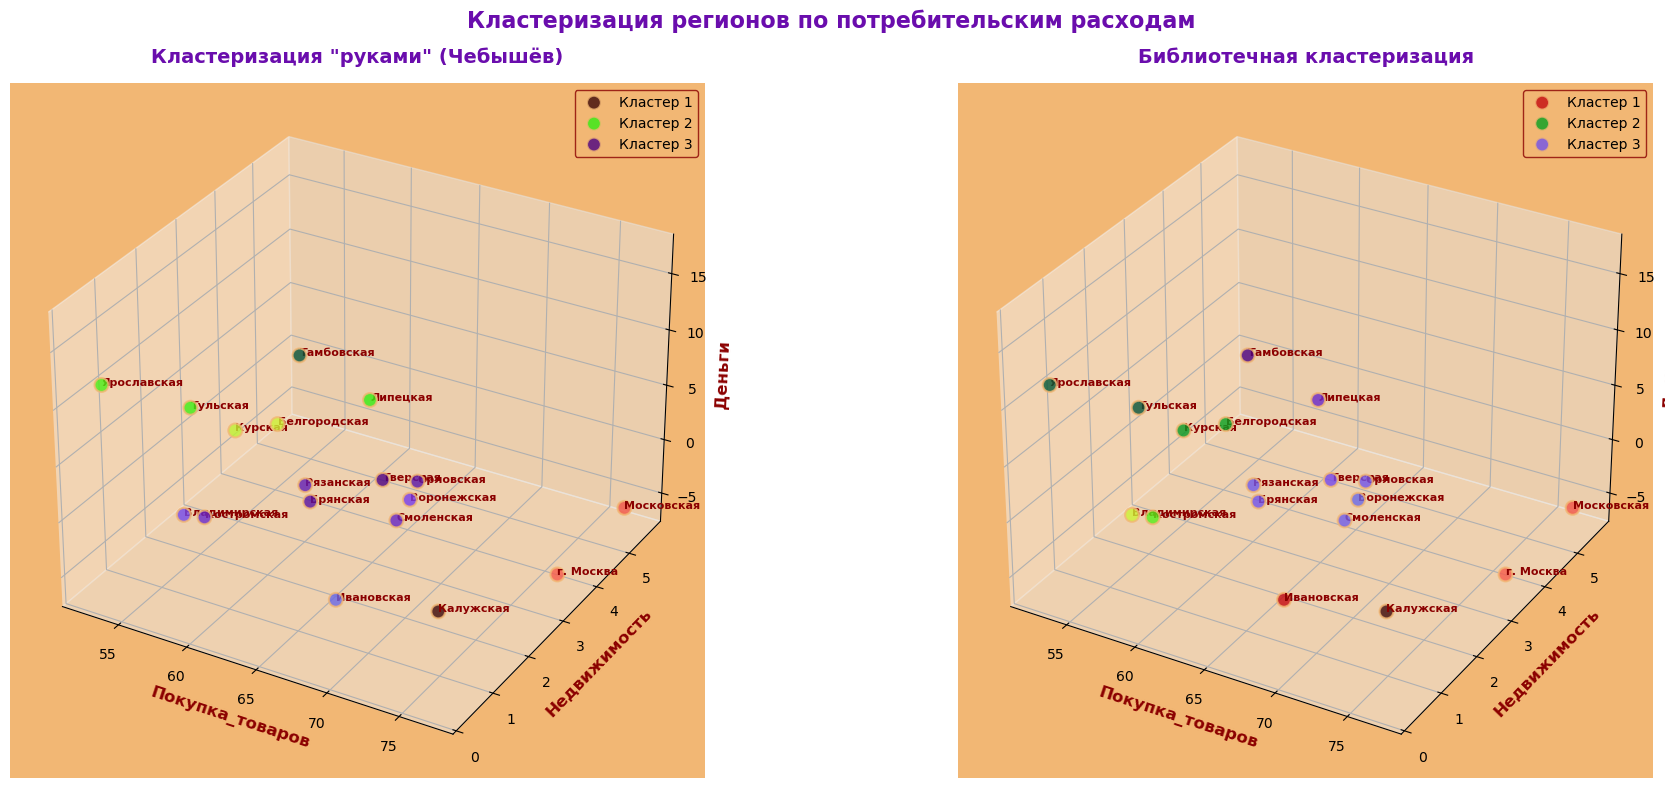


СОСТАВ КЛАСТЕРОВ

Самостоятельная кластеризация (Чебышёв):
Кластер 1 (3 объектов): ['Калужская', 'Московская', 'г. Москва']
Кластер 2 (6 объектов): ['Липецкая', 'Тамбовская', 'Ярославская', 'Тульская', 'Белгородская', 'Курская']
Кластер 3 (9 объектов): ['Тверская', 'Орловская', 'Смоленская', 'Воронежская', 'Брянская', 'Рязанская', 'Ивановская', 'Владимирская', 'Костромская']

Кластеризация с библиотекой:
Кластер 1 (4 объектов): ['Ивановская', 'Калужская', 'Московская', 'г. Москва']
Кластер 2 (6 объектов): ['Белгородская', 'Владимирская', 'Костромская', 'Курская', 'Тульская', 'Ярославская']
Кластер 3 (8 объектов): ['Брянская', 'Воронежская', 'Липецкая', 'Орловская', 'Рязанская', 'Смоленская', 'Тамбовская', 'Тверская']


In [41]:
# Второй датасет - потребительские расходы регионов
data_2 = {
    'Регионы': ['Белгородская', 'Брянская', 'Владимирская', 'Воронежская', 'Ивановская', 
                'Калужская', 'Костромская', 'Курская', 'Липецкая', 'Московская', 
                'Орловская', 'Рязанская', 'Смоленская', 'Тамбовская', 'Тверская', 
                'Тульская', 'Ярославская', 'г. Москва'],
    
    'Покупка_товаров': [62.3, 66.5, 56.5, 69.0, 66.9, 73.6, 60.4, 60.7, 68.0, 76.9, 
                 70.8, 64.5, 70.9, 65.3, 70.2, 59.0, 52.6, 76.8],
    
    'Недвижимость': [1.5, 0.8, 1.1, 2.5, 1.3, 1.5, 0.3, 1.0, 1.8, 5.6, 
                 2.0, 1.4, 1.4, 1.0, 1.3, 0.5, 0.5, 3.6],
    
    'Деньги': [8.4, 5.2, -0.7, 1.2, -5.0, -4.0, 3.0, 8.7, 11.7, -5.9, 
                 5.0, 4.1, 3.4, 16.8, 7.0, 11.5, 11.2, -6.0]
}

# Вычисление матрицы расстояний для д2 (метод Чебышёва)
df2 = pd.DataFrame(data_2)
points = df2[['Покупка_товаров', 'Недвижимость', 'Деньги']].values
distance_matrix1 = chebyshev_distance(points)
print("Матрица расстояний Чебышёва для второго датасета:")
print(distance_matrix1)

# Вычисление Варда для д2
clusters2 = ward_clustering(distance_matrix1, 3)
print("Результаты кластеризации:", clusters2)

# Построение диаграмм рассеивания для д2
universal_clustering_plot(data_2, clusters2, 3, None, labels_col='Регионы', title="Кластеризация регионов по потребительским расходам")

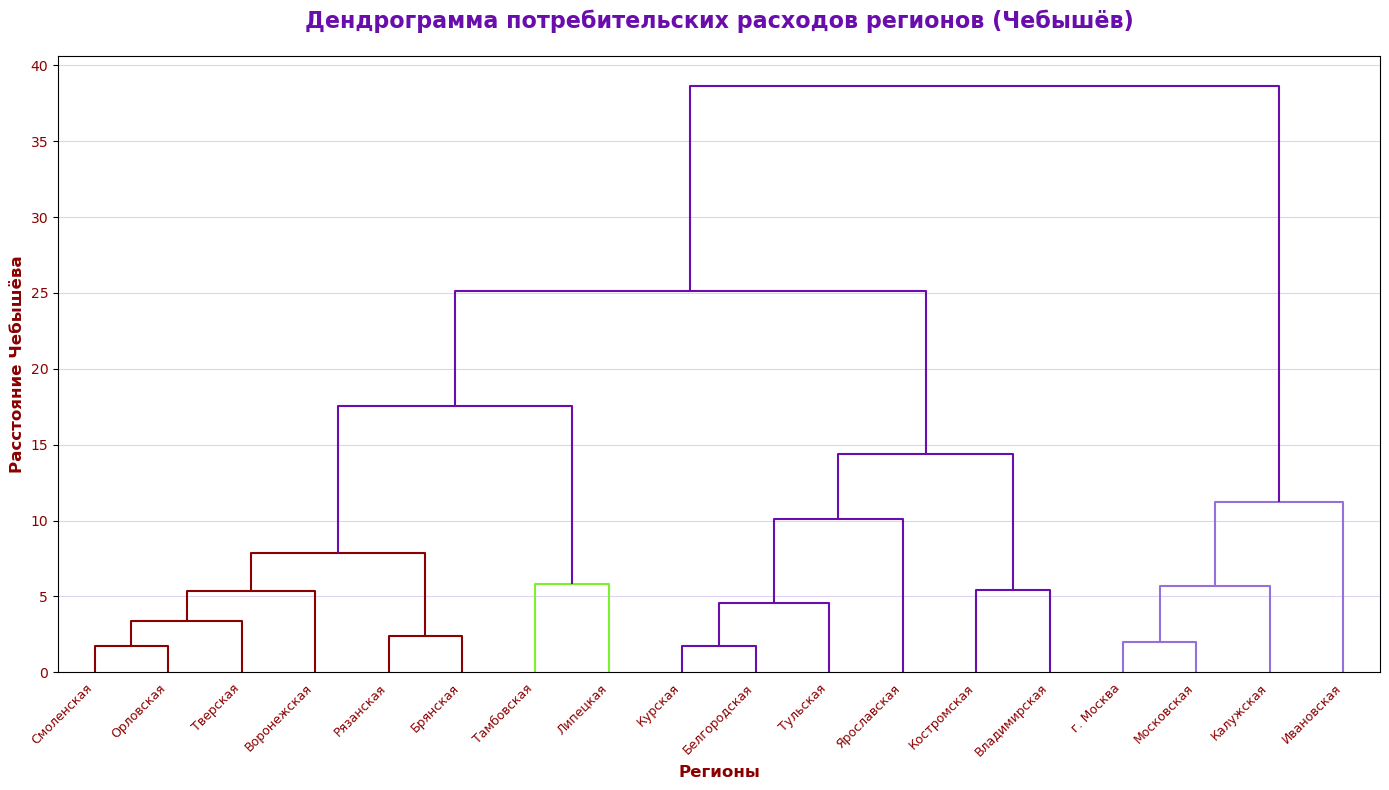

In [42]:
# Построение дендрограммы для д2
points = np.column_stack([data_2['Покупка_товаров'], data_2['Недвижимость'], data_2['Деньги']])
linkage_matrix = linkage(points, method='ward', metric='euclidean')
set_link_color_palette([wine_red, pale_yellow_green, purple, light_purple, light_red])

plt.figure(figsize=(14, 8))
ddata = dendrogram(linkage_matrix,
                   labels=data_2['Регионы'],
                   orientation='top',
                   distance_sort='descending',
                   show_leaf_counts=True,
                   leaf_font_size=9,
                   leaf_rotation=45,
                   color_threshold=15,
                   above_threshold_color=purple)

plt.title('Дендрограмма потребительских расходов регионов (Чебышёв)', fontsize=16, fontweight='bold', color=purple, pad=20)
plt.xlabel('Регионы', fontsize=12, color=wine_red, fontweight='bold')
plt.ylabel('Расстояние Чебышёва', fontsize=12, color=wine_red, fontweight='bold')
plt.xticks(rotation=45, ha='right', color=wine_red)
plt.yticks(color=wine_red)
plt.grid(axis='y', alpha=0.3, color=light_purple)
plt.tight_layout()
plt.show()

In [43]:
# Третий датасет - Химические свойства вина из CSV файла
print("ЗАГРУЗКА ДАТАСЕТА ВИНА ИЗ CSV ФАЙЛА")
print("=" * 50)


data3 = pd.read_csv('winequality-white.csv', delimiter=';', nrows=50)  # Читаем только первые 50 строк CSV файла с разделителем ;


data3['wine_id'] = [f"Wine_{i+1}" for i in range(len(data3))]  # Создаем уникальные идентификаторы вин

print("Датасет химических свойств вина (первые 50 строк):")
print(f"Размер: {data3.shape}")  
print("\nПервые 5 строк данных:")
print(data3.head())  # Показываем первые 5 строк

print("\nИнформация о данных:")
print(data3.info())  # Показываем информацию о типах данных и наличии пропусков

print("\nОсновные статистические характеристики:")
print(data3.describe())  # Показываем статистику по числовым колонкам

ЗАГРУЗКА ДАТАСЕТА ВИНА ИЗ CSV ФАЙЛА
Датасет химических свойств вина (первые 50 строк):
Размер: (50, 13)

Первые 5 строк данных:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                   45                   170   1.0010  3.00       0.45   
1                   14                   132   0.9940  3.30       0.49   
2                   30                    97   0.9951  3.26       0.44   
3                   47                   186   0.9956  3.19       0.40   
4                   47           

In [44]:
# Предобработка данных вина
print("ПРЕДОБРАБОТКА ДАННЫХ ВИНА")
print("=" * 40)

# Выбираем только числовые колонки (все химические свойства)
numeric_data = data3.select_dtypes(include=[np.number])  # Выбираем все числовые столбцы

# Исключаем quality из признаков для кластеризации, но оставляем для визуализации
features_for_clustering = [col for col in numeric_data.columns if col != 'quality']  # Убираем качество из признаков

print("Числовые данные для кластеризации:")
print(numeric_data[features_for_clustering].head())  # Показываем признаки для кластеризации

# Получаем метки (идентификаторы вин)
labels = data3['wine_id'].tolist()  # Используем wine_id как метки для дендрограммы

# Масштабируем данные для лучшей кластеризации
X = numeric_data[features_for_clustering].values  # Берем только признаки для кластеризации
scaler = StandardScaler()  # Создаем стандартизатор
X_scaled = scaler.fit_transform(X)  # Масштабируем данные (среднее=0, std=1)

print(f"\nРазмерность данных после масштабирования: {X_scaled.shape}")  # Выводим размерность
print("Первые 5 строк масштабированных данных:")
print(X_scaled[:5])  # Показываем первые 5 строк масштабированных данных

ПРЕДОБРАБОТКА ДАННЫХ ВИНА
Числовые данные для кластеризации:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                   45                   170   1.0010  3.00       0.45   
1                   14                   132   0.9940  3.30       0.49   
2                   30                    97   0.9951  3.26       0.44   
3                   47                   186   0.9956  3.19       0.40   
4                   47                   186   0.9956  3.19       0.40   

   alcohol  
0      8.8  

In [45]:
# Построение матрицы расстояний для датасета вина с использованием метода Чебышёва
print("ВЫЧИСЛЕНИЕ МАТРИЦЫ РАССТОЯНИЙ ЧЕБЫШЁВА")
print("=" * 50)

df3 = pd.DataFrame(data3)  # Создаем DataFrame из данных вина
numeric_columns = df3[features_for_clustering].columns  # Выбираем числовые столбцы для кластеризации
points3 = df3[numeric_columns].values  # Извлекаем значения химических свойств

# ВЫЧИСЛЯЕМ МАТРИЦУ РАССТОЯНИЙ МЕТОДОМ ЧЕБЫШЁВА
distance_matrix3 = chebyshev_distance(points3)  # Используем метод Чебышёва

print("Матрица расстояний Чебышёва для химических свойств вина:")
print(f"Размер матрицы: {distance_matrix3.shape}")  # Выводим размер матрицы
print("Первые 5x5 элементов матрицы:")
print(distance_matrix3[:5, :5])  # Показываем первые 5x5 элементов матрицы

ВЫЧИСЛЕНИЕ МАТРИЦЫ РАССТОЯНИЙ ЧЕБЫШЁВА
Матрица расстояний Чебышёва для химических свойств вина:
Размер матрицы: (50, 50)
Первые 5x5 элементов матрицы:
[[ 0. 38. 73. 16. 16.]
 [38.  0. 35. 54. 54.]
 [73. 35.  0. 89. 89.]
 [16. 54. 89.  0.  0.]
 [16. 54. 89.  0.  0.]]


In [46]:
# Кластеризация Варда для датасета вина
print("КЛАСТЕРИЗАЦИЯ ВИН МЕТОДОМ ВАРДА")
print("=" * 40)

clusters3 = ward_clustering(distance_matrix3, 3)  # Кластеризуем вина на 3 кластера
print("Результаты кластеризации вин:")
print(clusters3)  # Выводим индексы вин в кластерах

# Анализ состава кластеров
print("\nАНАЛИЗ КЛАСТЕРОВ ВИН:")
print("=" * 50)
for i, cluster in enumerate(clusters3):
    cluster_wines = [data3['wine_id'].iloc[idx] for idx in cluster]  # Получаем названия вин в кластере
    cluster_qualities = [data3['quality'].iloc[idx] for idx in cluster]  # Получаем качества вин
    avg_quality = np.mean(cluster_qualities)  # Среднее качество в кластере
    
    print(f"Кластер {i+1} ({len(cluster)} вин):")
    print(f"  Вина: {cluster_wines}")
    print(f"  Качества: {cluster_qualities}")
    print(f"  Среднее качество: {avg_quality:.2f}")
    print()

КЛАСТЕРИЗАЦИЯ ВИН МЕТОДОМ ВАРДА
Итерация 0:
Размер матрицы расстояний: (50, 50)
Матрица расстояний:
[[  0.    38.    73.    16.    16.    73.    34.     0.    38.    41.   107.    61.    95.    27.     4.    58.    71.    95.    28.    37.    95.    68.    48.    20.    29.    75.    24.    29.
   38.    56.    28.   123.    70.    53.    23.    47.    21.    32.    21.    21.    18.2   18.    17.    19.3   19.3   19.3   36.    37.    17.    20.  ]
 [ 38.     0.    35.    54.    54.    35.    16.    38.     0.    14.    69.    23.    57.    34.    40.    20.    33.    57.    39.    20.    57.    30.    27.    36.    10.   113.    21.    18.
    3.    23.    10.    85.    32.    29.    47.     9.    17.    24.    31.    31.    49.    49.    28.    20.    22.    35.    74.    75.    28.    18.  ]
 [ 73.    35.     0.    89.    89.     0.    39.    73.    35.    32.    34.    13.    22.    46.    75.    15.     5.8   22.    74.    36.    22.    11.    25.    71.    45.   148.    49.    44

ПОСТРОЕНИЕ ДИАГРАММ РАССЕИВАНИЯ ДЛЯ ВИНА
Используемые признаки для визуализации: ['alcohol', 'volatile acidity', 'quality']


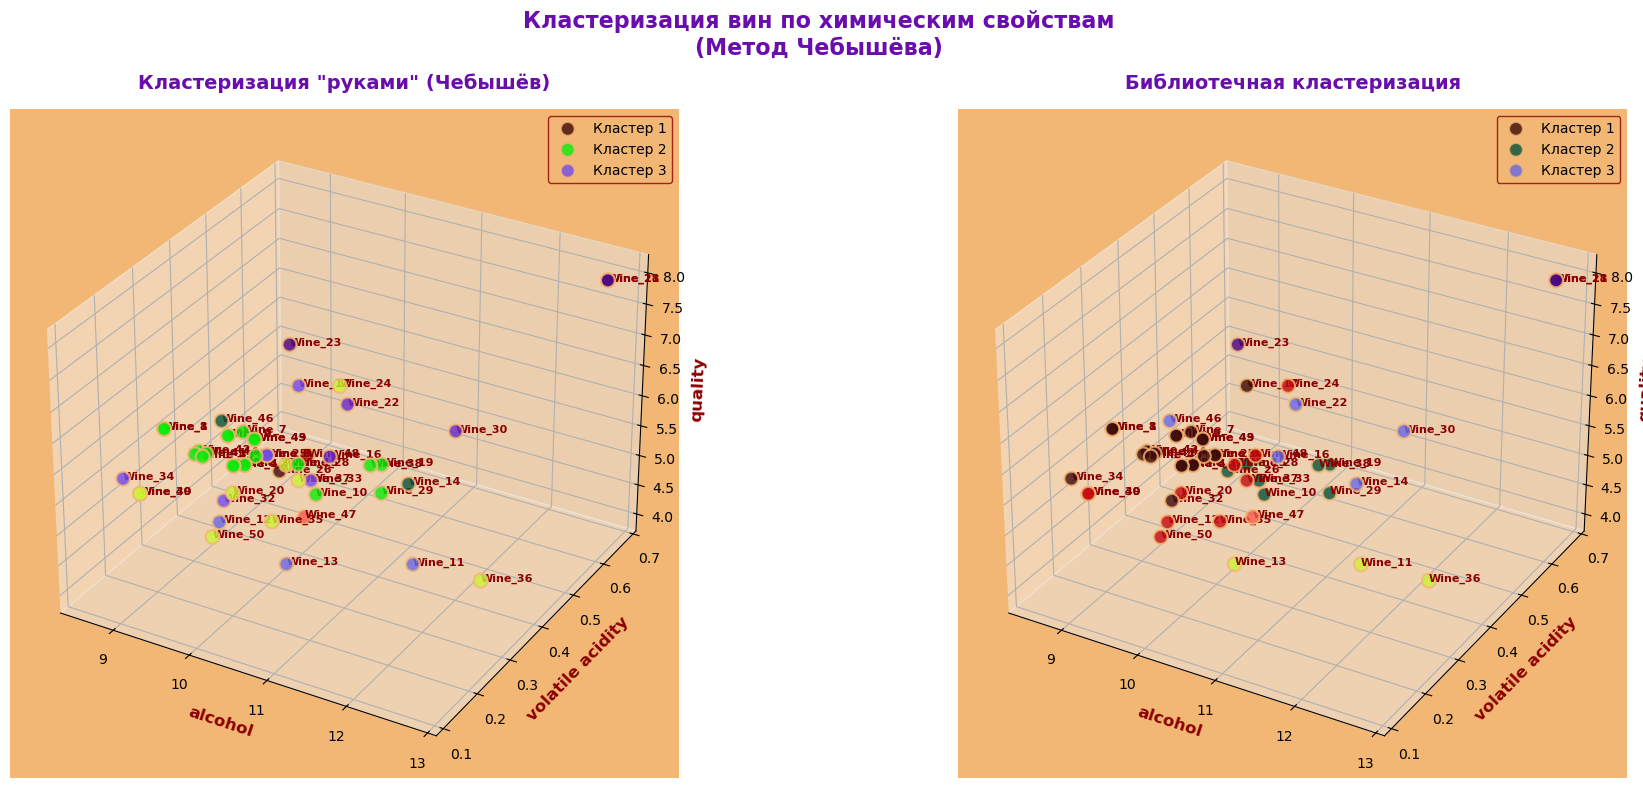


СОСТАВ КЛАСТЕРОВ

Самостоятельная кластеризация (Чебышёв):
Кластер 1 (3 объектов): ['Wine_26', 'Wine_47', 'Wine_48']
Кластер 2 (32 объектов): ['Wine_4', 'Wine_5', 'Wine_15', 'Wine_1', 'Wine_8', 'Wine_35', 'Wine_19', 'Wine_24', 'Wine_44', 'Wine_45', 'Wine_27', 'Wine_50', 'Wine_46', 'Wine_43', 'Wine_49', 'Wine_25', 'Wine_31', 'Wine_37', 'Wine_29', 'Wine_2', 'Wine_9', 'Wine_10', 'Wine_36', 'Wine_14', 'Wine_41', 'Wine_42', 'Wine_39', 'Wine_40', 'Wine_38', 'Wine_28', 'Wine_7', 'Wine_20']
Кластер 3 (15 объектов): ['Wine_32', 'Wine_18', 'Wine_21', 'Wine_11', 'Wine_13', 'Wine_30', 'Wine_23', 'Wine_34', 'Wine_3', 'Wine_6', 'Wine_17', 'Wine_33', 'Wine_16', 'Wine_12', 'Wine_22']

Кластеризация с библиотекой:
Кластер 1 (32 объектов): ['Wine_1', 'Wine_2', 'Wine_3', 'Wine_4', 'Wine_5', 'Wine_6', 'Wine_7', 'Wine_8', 'Wine_9', 'Wine_12', 'Wine_15', 'Wine_17', 'Wine_20', 'Wine_24', 'Wine_25', 'Wine_27', 'Wine_31', 'Wine_32', 'Wine_34', 'Wine_35', 'Wine_37', 'Wine_39', 'Wine_40', 'Wine_41', 'Wine_42', 

In [47]:
# Построение диаграмм рассеивания для датасета вина с градиентами
print("ПОСТРОЕНИЕ ДИАГРАММ РАССЕИВАНИЯ ДЛЯ ВИНА")
print("=" * 45)

# Выбираем наиболее информативные признаки для визуализации
selected_features = ['alcohol', 'volatile acidity', 'quality']  # Алкоголь, летучая кислотность и качество

print(f"Используемые признаки для визуализации: {selected_features}")

# Строим графики с использованием улучшенной функции с градиентами
universal_clustering_plot(data3, clusters3, 3, features=selected_features, 
                         labels_col='wine_id', 
                         title="Кластеризация вин по химическим свойствам\n(Метод Чебышёва)",
                         figsize=(20, 8))

ПОСТРОЕНИЕ ДИАГРАММ РАССЕИВАНИЯ ДЛЯ ВИНА
Используемые признаки для визуализации: ['alcohol', 'volatile acidity', 'quality']


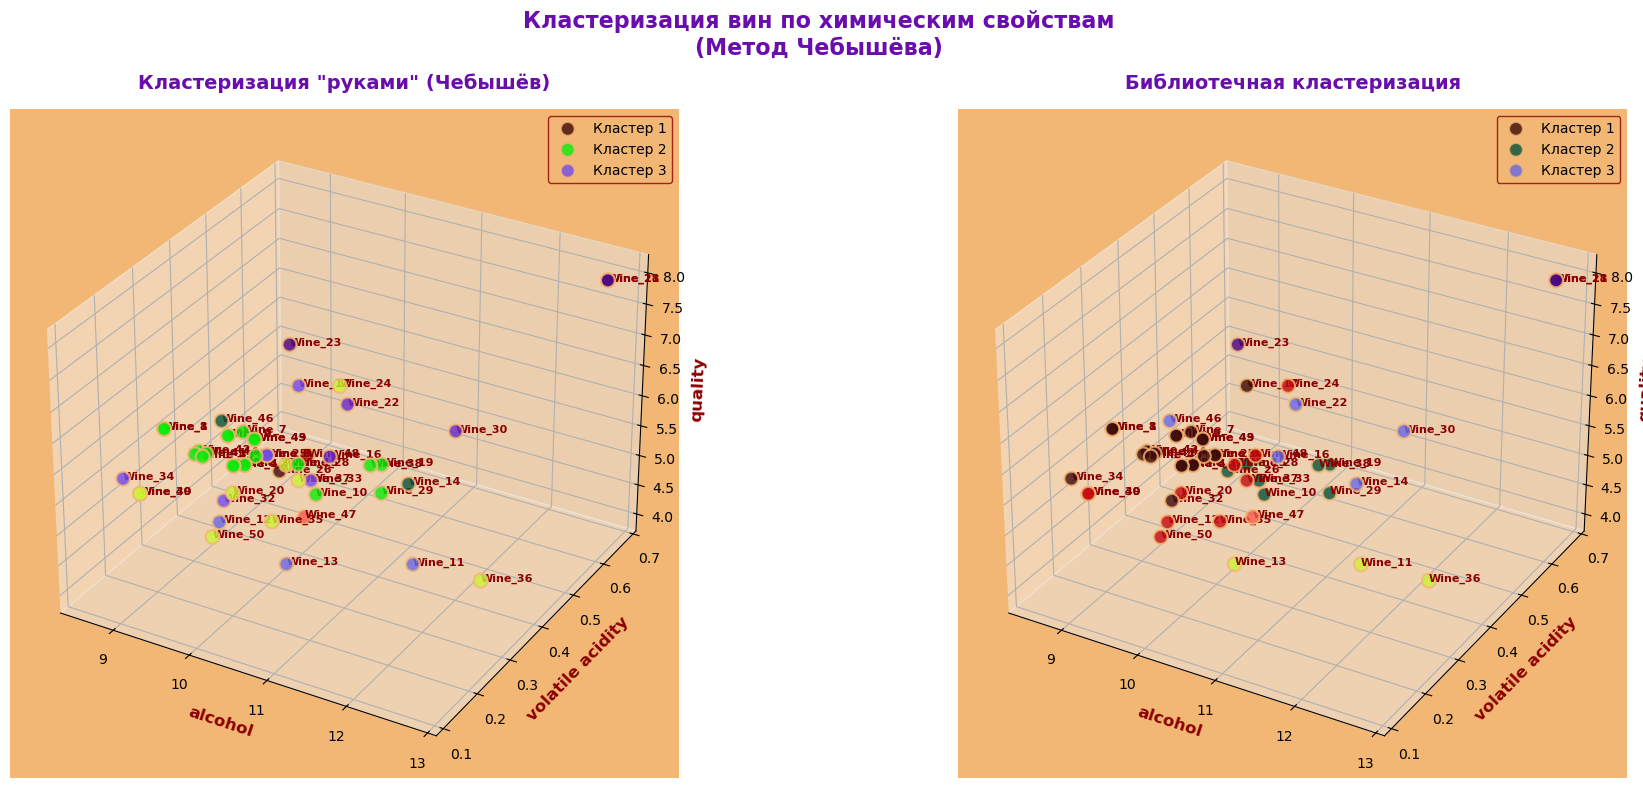


СОСТАВ КЛАСТЕРОВ

Самостоятельная кластеризация (Чебышёв):
Кластер 1 (3 объектов): ['Wine_26', 'Wine_47', 'Wine_48']
Кластер 2 (32 объектов): ['Wine_4', 'Wine_5', 'Wine_15', 'Wine_1', 'Wine_8', 'Wine_35', 'Wine_19', 'Wine_24', 'Wine_44', 'Wine_45', 'Wine_27', 'Wine_50', 'Wine_46', 'Wine_43', 'Wine_49', 'Wine_25', 'Wine_31', 'Wine_37', 'Wine_29', 'Wine_2', 'Wine_9', 'Wine_10', 'Wine_36', 'Wine_14', 'Wine_41', 'Wine_42', 'Wine_39', 'Wine_40', 'Wine_38', 'Wine_28', 'Wine_7', 'Wine_20']
Кластер 3 (15 объектов): ['Wine_32', 'Wine_18', 'Wine_21', 'Wine_11', 'Wine_13', 'Wine_30', 'Wine_23', 'Wine_34', 'Wine_3', 'Wine_6', 'Wine_17', 'Wine_33', 'Wine_16', 'Wine_12', 'Wine_22']

Кластеризация с библиотекой:
Кластер 1 (32 объектов): ['Wine_1', 'Wine_2', 'Wine_3', 'Wine_4', 'Wine_5', 'Wine_6', 'Wine_7', 'Wine_8', 'Wine_9', 'Wine_12', 'Wine_15', 'Wine_17', 'Wine_20', 'Wine_24', 'Wine_25', 'Wine_27', 'Wine_31', 'Wine_32', 'Wine_34', 'Wine_35', 'Wine_37', 'Wine_39', 'Wine_40', 'Wine_41', 'Wine_42', 

In [48]:
# Построение диаграмм рассеивания для датасета вина с градиентами
print("ПОСТРОЕНИЕ ДИАГРАММ РАССЕИВАНИЯ ДЛЯ ВИНА")
print("=" * 45)

# Выбираем наиболее информативные признаки для визуализации
selected_features = ['alcohol', 'volatile acidity', 'quality']  # Алкоголь, летучая кислотность и качество

print(f"Используемые признаки для визуализации: {selected_features}")

# Строим графики с использованием улучшенной функции с градиентами
universal_clustering_plot(data3, clusters3, 3, features=selected_features, 
                         labels_col='wine_id', 
                         title="Кластеризация вин по химическим свойствам\n(Метод Чебышёва)",
                         figsize=(20, 8))

ПОСТРОЕНИЕ ДЕНДРОГРАММЫ ДЛЯ ВИНА


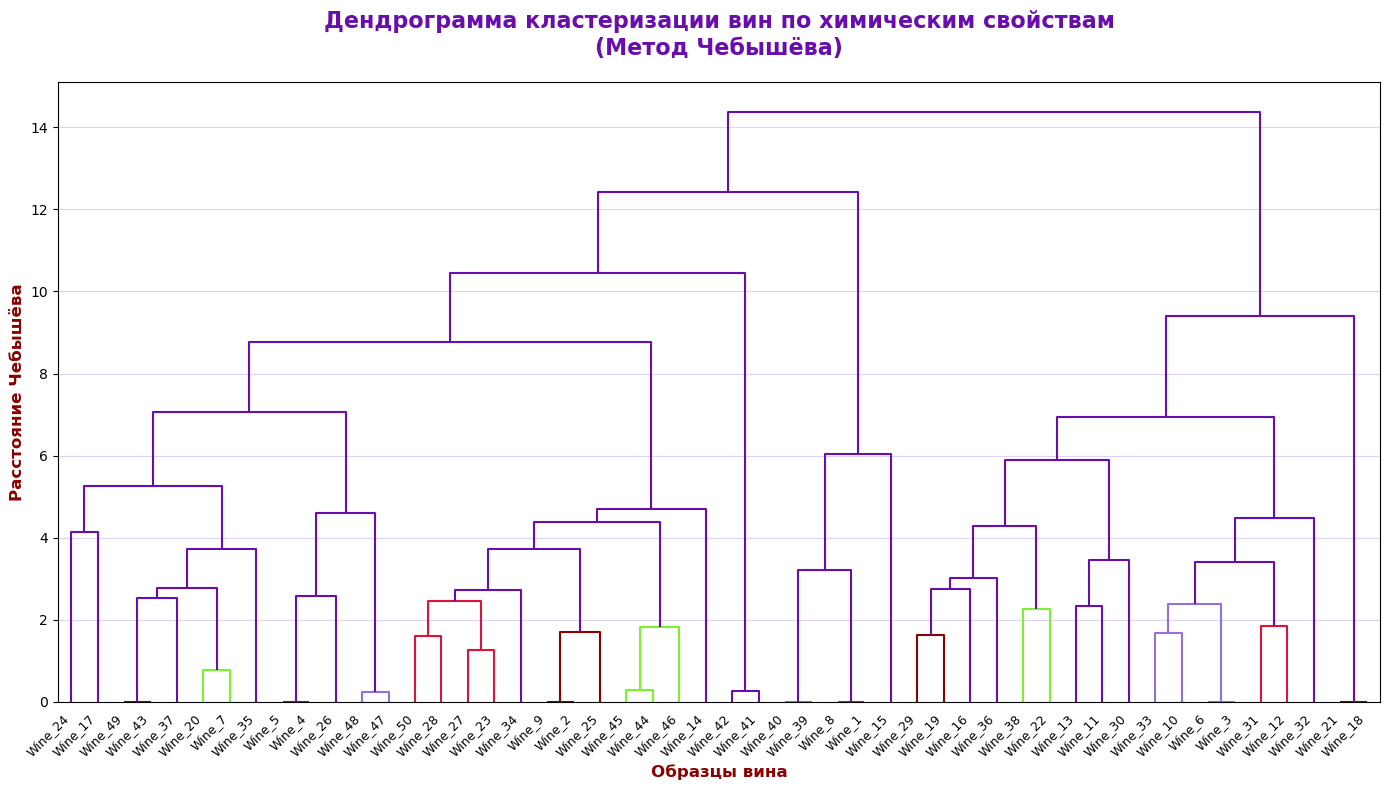

In [49]:
# Построение дендрограммы для датасета вина
print("ПОСТРОЕНИЕ ДЕНДРОГРАММЫ ДЛЯ ВИНА")
print("=" * 40)

# Используем масштабированные данные для дендрограммы
linkage_matrix = linkage(X_scaled, method='ward', metric='euclidean')  # Строим матрицу связей

# Устанавливаем новую цветовую палитру (винная тематика)
set_link_color_palette([wine_red, pale_yellow_green, purple, light_purple, light_red])

# Строим дендрограмму с улучшенным дизайном
plt.figure(figsize=(14, 8))
dendrogram(linkage_matrix, 
           labels=labels,  # Используем идентификаторы вин как подписи
           orientation='top',  # Ориентация сверху вниз
           distance_sort='descending',  # Сортировка по убыванию расстояния
           show_leaf_counts=True,  # Показывать количество листьев
           leaf_font_size=9,  # Размер шрифта для подписей
           leaf_rotation=45,  # Поворот подписей для лучшей читаемости
           color_threshold=2.5,  # Порог для автоматической раскраски кластеров
           above_threshold_color=purple)  # Цвет связей выше порога

plt.title("Дендрограмма кластеризации вин по химическим свойствам\n(Метод Чебышёва)", 
          fontsize=16, fontweight='bold', color=purple, pad=20)
plt.xlabel("Образцы вина", fontsize=12, color=wine_red, fontweight='bold')
plt.ylabel("Расстояние Чебышёва", fontsize=12, color=wine_red, fontweight='bold')
plt.xticks(rotation=45, ha='right')  # Наклон подписей для удобства чтения
plt.grid(axis='y', alpha=0.3, color=light_purple)  # Добавляем сетку по оси Y
plt.tight_layout()  # Автоматическая настройка layout
plt.show()